In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
df=pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\INTERNSHIP\Airport\Airport_Flight_Data_550.xlsx.csv", header=0)
df

,Flight_ID,Flight_Date,Airline,Flight_Number,Origin_Airport,Destination_Airport,Scheduled_Departure,Actual_Departure,Departure_Delay_Min,Cancelled
0,30000,29-02-2024,SpiceJet,SG661,BLR,BLR,14:11,15:01,50,YES
1,30001,22-01-2024,Vistara,AI288,DEL,MAA,19:22,21:07,105,NO
2,30002,06-01-2024,SpiceJet,AI581,HYD,BLR,17:01,18:16,75,YES
3,30003,08-02-2024,SpiceJet,6E346,HYD,HYD,21:42,22:18,36,NO
4,30004,21-02-2024,Indigo,AI875,BOM,BOM,20:45,21:21,36,NO
...,...,...,...,...,...,...,...,...,...,...
545,30545,12-02-2024,Air India,AI917,DEL,DEL,04:41,06:02,81,NO
546,30546,15-02-2024,Indigo,SG911,DEL,HYD,17:43,18:26,43,YES
547,30547,20-01-2024,Indigo,AI253,DEL,HYD,16:14,16:32,18,NO
548,30548,06-03-2024,SpiceJet,6E984,BOM,HYD,18:12,19:49,97,NO


In [6]:
df.head()

,Flight_ID,Flight_Date,Airline,Flight_Number,Origin_Airport,Destination_Airport,Scheduled_Departure,Actual_Departure,Departure_Delay_Min,Cancelled
0,30000,29-02-2024,SpiceJet,SG661,BLR,BLR,14:11,15:01,50,YES
1,30001,22-01-2024,Vistara,AI288,DEL,MAA,19:22,21:07,105,NO
2,30002,06-01-2024,SpiceJet,AI581,HYD,BLR,17:01,18:16,75,YES
3,30003,08-02-2024,SpiceJet,6E346,HYD,HYD,21:42,22:18,36,NO
4,30004,21-02-2024,Indigo,AI875,BOM,BOM,20:45,21:21,36,NO


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Flight_ID            550 non-null    int64 
 1   Flight_Date          550 non-null    object
 2   Airline              550 non-null    object
 3   Flight_Number        550 non-null    object
 4   Origin_Airport       550 non-null    object
 5   Destination_Airport  550 non-null    object
 6   Scheduled_Departure  550 non-null    object
 7   Actual_Departure     550 non-null    object
 8   Departure_Delay_Min  550 non-null    int64 
 9   Cancelled            550 non-null    object
dtypes: int64(2), object(8)
memory usage: 43.1+ KB


In [8]:
df.describe(include="all")

,Flight_ID,Flight_Date,Airline,Flight_Number,Origin_Airport,Destination_Airport,Scheduled_Departure,Actual_Departure,Departure_Delay_Min,Cancelled
count,550.000000,550,550,550,550,550,550,550,550.000000,550
unique,NaN,70,4,497,5,5,458,452,NaN,3
top,NaN,21-01-2024,Indigo,AI735,DEL,HYD,16:00,08:44,NaN,YES
freq,NaN,15,149,3,127,121,3,3,NaN,191
mean,30274.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.574545,NaN
std,158.915596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.337129,NaN
min,30000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.000000,NaN
25%,30137.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.000000,NaN
50%,30274.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,61.000000,NaN
75%,30411.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.000000,NaN


In [9]:
df.isnull().sum()

Flight_ID              0
Flight_Date            0
Airline                0
Flight_Number          0
Origin_Airport         0
Destination_Airport    0
Scheduled_Departure    0
Actual_Departure       0
Departure_Delay_Min    0
Cancelled              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [5]:
df["Cancelled"].unique()

<ArrowStringArray>
[' YES', 'NO ', 'NO']
Length: 3, dtype: str

In [6]:
df["Cancelled"]=df["Cancelled"].replace({" YES":"YES","NO ":"NO"})

In [7]:
df["Cancelled"].unique()

<ArrowStringArray>
['YES', 'NO']
Length: 2, dtype: str

In [8]:
#Create New Column
def delay_category(x):
    if x <= 15:
        return "On Time"
    elif x <= 60:
        return "Minor Delay"
    else:
        return "Major Delay"

df['Delay_Category'] = df['Departure_Delay_Min'].apply(delay_category)

In [9]:
df.to_csv(r"C:\Users\hp\OneDrive\Desktop\INTERNSHIP\Airport\Airline.csv",index=False)

In [10]:
df.head()

,Flight_ID,Flight_Date,Airline,Flight_Number,Origin_Airport,Destination_Airport,Scheduled_Departure,Actual_Departure,Departure_Delay_Min,Cancelled,Delay_Category
0,30000,29-02-2024,SpiceJet,SG661,BLR,BLR,14:11,15:01,50,YES,Minor Delay
1,30001,22-01-2024,Vistara,AI288,DEL,MAA,19:22,21:07,105,NO,Major Delay
2,30002,06-01-2024,SpiceJet,AI581,HYD,BLR,17:01,18:16,75,YES,Major Delay
3,30003,08-02-2024,SpiceJet,6E346,HYD,HYD,21:42,22:18,36,NO,Minor Delay
4,30004,21-02-2024,Indigo,AI875,BOM,BOM,20:45,21:21,36,NO,Minor Delay


In [11]:
#Exploratory Data Analysis (EDA)
df['Airline'].value_counts()

Airline
Indigo       149
Air India    148
SpiceJet     138
Vistara      115
Name: count, dtype: int64

In [12]:
df['Departure_Delay_Min'].mean()

np.float64(60.57454545454546)

In [13]:
df['Delay_Category'].value_counts()

Delay_Category
Major Delay    276
Minor Delay    194
On Time         80
Name: count, dtype: int64

In [14]:
df['Cancelled'].value_counts()

Cancelled
NO     359
YES    191
Name: count, dtype: int64

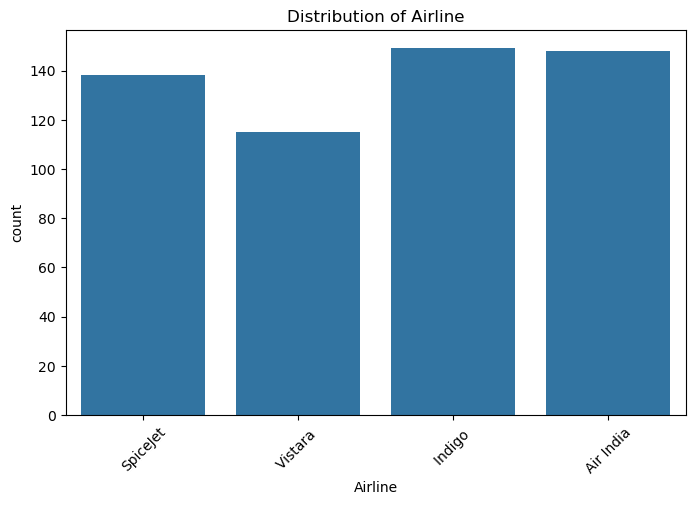

In [61]:
sns.countplot(x='Airline', data=df)
plt.title('Distribution of Airline')
plt.xticks(rotation=45)
plt.show()

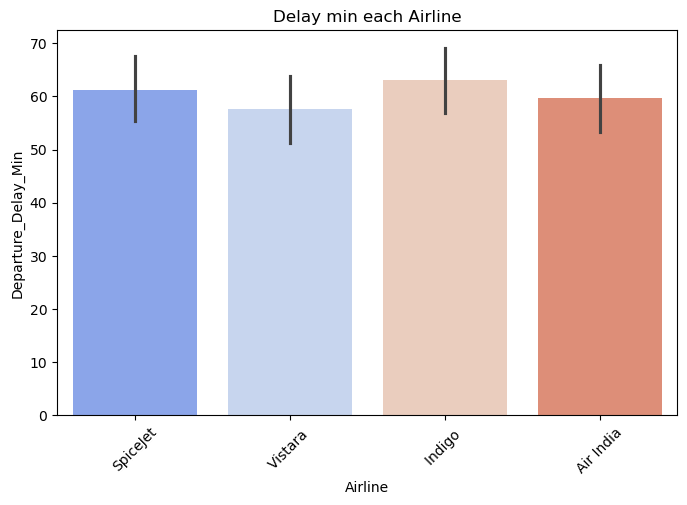

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x='Airline', y='Departure_Delay_Min', data=df, palette='coolwarm')
plt.title('Delay min each Airline')
plt.xticks(rotation=45)
plt.show()

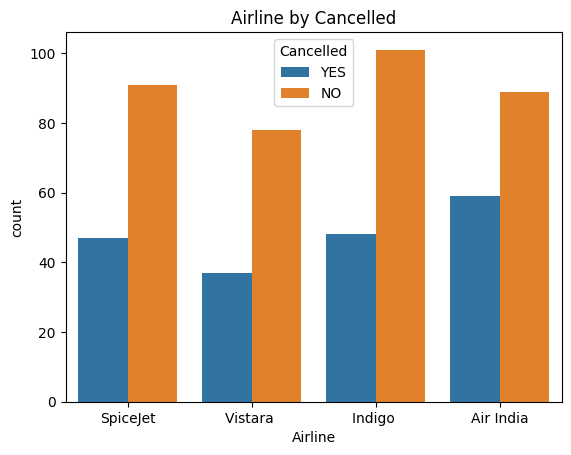

In [17]:
sns.countplot(data=df, x='Airline', hue='Cancelled')
plt.title("Airline by Cancelled")
plt.show()

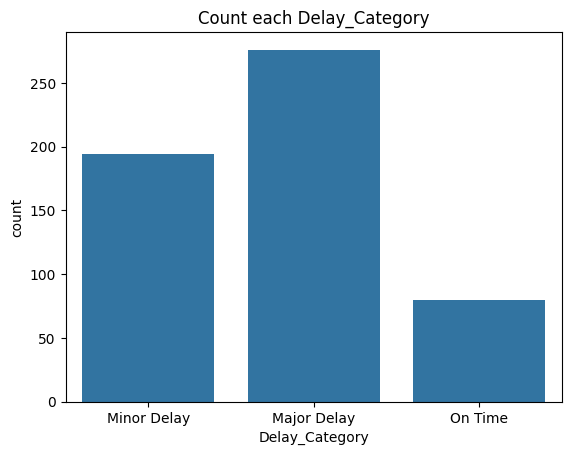

In [22]:
sns.countplot(x='Delay_Category', data=df)
plt.title("Count each Delay_Category")
plt.show()